# 17 Figure 6 Physics-aware Descriptor Modeling and Virtual Design

Purpose:
This notebook prepares draft plots and exported data for Figure 6.

Figure 6A:
- Compact explicit descriptor model
- Elastic Net coefficient plot

Figure 6B:
- Linear descriptor model vs polynomial descriptor model comparison

Figure 6C:
- Virtual design map across resistance and structure descriptors

Figure 6D:
- Ranked virtual descriptor combinations

Important:
The goal is not to claim experimental optimization of real devices.
The goal is to translate descriptor-level machine-learning results into interpretable design logic.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

out_dir = Path("../results/figure6_virtual_design")
out_dir.mkdir(parents=True, exist_ok=True)

print("Output folder:", out_dir.resolve())

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.linewidth"] = 1.0

Output folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure6_virtual_design


In [3]:
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "yellow": "#F0E442",
    "black": "#000000",
    "gray": "#666666",
    "light_gray": "#DDDDDD",
    "very_light_gray": "#F2F2F2"
}

In [4]:
candidate_files = [
    "hydrovoltaic_dataset_phase2_input_utf8.csv",
    "hydrovoltaic_model_input.csv",
    "hydrovoltaic_clean.csv",
    "../data/processed/hydrovoltaic_dataset_phase2_input_utf8.csv",
    "../data/processed/hydrovoltaic_model_input.csv",
    "../data/processed/hydrovoltaic_clean.csv",
    "../notebooks/hydrovoltaic_dataset_phase2_input_utf8.csv",
    "../notebooks/hydrovoltaic_model_input.csv",
    "../notebooks/hydrovoltaic_clean.csv",
]

data_path = None

for f in candidate_files:
    p = Path(f)
    if p.exists():
        data_path = p
        break

if data_path is None:
    print("CSV files in current folder:")
    for f in Path(".").glob("*.csv"):
        print(" -", f.name)
    print("CSV files in parent folder:")
    for f in Path("..").glob("*.csv"):
        print(" -", f.name)
    raise FileNotFoundError("Please update candidate_files with the correct dataset path.")

df = pd.read_csv(data_path, encoding="utf-8-sig")

print("Loaded:", data_path)
print("Dataset shape:", df.shape)
display(df.head())

Loaded: hydrovoltaic_dataset_phase2_input_utf8.csv
Dataset shape: (159, 52)


,paper_doi,review_covered,ref_year,device_structure,built_in_asymmetry,asymmetry_origin,primary_mobile_ion,secondary_ion_present,secondary_mobile_ion,ion_origin,auxiliary_redox_present,continuous_output,water_interaction_mode,rh_percent,inorganic_electrolyte_present,inorganic_electrolyte_type,inorganic_electrolyte_concentration_wt%,polyelectrolyte_present,active_material_raw,material_class,structure_class,ionic_groups,top_electrode,bottom_electrode,electrode_symmetry,metal_electrode,voc_V,jsc_uA_cm2,power_density_uW_cm2,internal_resistance_Mohm,output_timescale_class,stability_time_min,dominant_mechanism,has_anionic,has_cationic,has_zwitterionic,polyelectrolyte_anionic_raw,polyelectrolyte_cationic_raw,polyelectrolyte_zwitterionic_raw,has_any_polyelectrolyte,estimated_power_density_uW_cm2,log_estimated_power_density,ion_type,asym_env,asym_chem,asym_electrode,mechanism_simple,ion_from_material,ion_from_electrolyte,ion_from_water,log_internal_resistance_Mohm,has_internal_resistance
0,10.1038/nnano.2016.300,1,2017,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,60.0,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,1.00,0.0150,0.0053,8.0,days,11520.0,streaming,0,0,0,NaN,NaN,NaN,0,0.003750,-2.425853,proton,1,0,0,streaming,1,0,0,0.903090,1
1,10.1021/acsaelm.9b00419,1,2019,in-plane,0,environmental_gradient,OH-,1,H+,water_dissociation,0,1,evaporation_driven,62.0,0,NaN,NaN,0,ZnO,metal oxide,porous,hydroxyl,Al,Al,1,1.0,0.40,0.0200,0.0020,34.3,hours,120.0,streaming,0,0,0,NaN,NaN,NaN,0,0.002000,-2.698753,anion,1,0,0,streaming,0,0,1,1.535294,1
2,10.1002/adma.202514202,0,2026,in-plane,1,chemical + environmental,OH-,1,H+,water_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,lanthanum iron perovskite oxide,semiconductor,porous,hydroxyl,CNT,CNT,1,0.0,1.50,0.0250,0.0094,60.0,days,12000.0,streaming,0,0,0,NaN,NaN,NaN,0,0.009375,-2.027982,anion,1,1,0,streaming,0,0,1,1.778151,1
3,10.1016/j.joule.2022.02.002,1,2022,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,NaN,0,NaN,NaN,0,Carbon Black (CB),carbon,porous,"carboxyl, hydroxyl",CNT,CNT,1,0.0,0.85,0.0368,NaN,NaN,hours,720.0,streaming,0,0,0,NaN,NaN,NaN,0,0.007820,-2.106738,proton,1,0,0,streaming,1,0,0,NaN,0
4,10.1016/j.ceramint.2023.05.033,0,2023,in-plane,0,environmental_gradient,H+,0,NaN,surface_group_dissociation,0,1,evaporation_driven,55.0,0,NaN,NaN,0,carbonized rice husk,carbon,porous,"carboxyl, hydroxyl, silanol",CNT,CNT,1,0.0,0.16,0.0400,NaN,NaN,hours,600.0,streaming,0,0,0,NaN,NaN,NaN,0,0.001600,-2.795609,proton,1,0,0,streaming,1,0,0,NaN,0


In [5]:
def find_first_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def find_column_by_keywords(df, keywords):
    keywords = [k.lower() for k in keywords]
    for c in df.columns:
        c_low = c.lower()
        if all(k in c_low for k in keywords):
            return c
    return None


def show_candidate_columns(df, keyword):
    return [c for c in df.columns if keyword.lower() in c.lower()]

In [6]:
target_log_candidates = [
    "log_P_est",
    "log_Pest",
    "log_estimated_power_density",
    "log_estimated_power_density_uW_cm2",
]

target_raw_candidates = [
    "P_est",
    "Pest",
    "estimated_power_density",
    "estimated_power_density_uW_cm2",
]

R_log_candidates = [
    "log_internal_resistance_Mohm",
    "log_internal_resistance_MΩ",
    "log_R",
    "logR",
]

R_raw_candidates = [
    "internal_resistance_Mohm",
    "internal_resistance_MΩ",
    "internal_resistance",
    "R_Mohm",
]

structure_candidates = [
    "structure_class",
    "device_structure",
    "structure",
]

ion_candidates = [
    "ion_type",
    "primary_mobile_ion_type",
    "mobile_ion_type",
]

inorganic_candidates = [
    "inorganic_electrolyte_present",
    "electrolyte_inorganic_present",
    "has_inorganic_electrolyte",
]

mechanism_candidates = [
    "mechanism_simple",
    "mechanism_label",
    "mechanism",
]

TARGET_LOG_COL = find_first_existing_column(df, target_log_candidates)
TARGET_RAW_COL = find_first_existing_column(df, target_raw_candidates)

R_LOG_COL = find_first_existing_column(df, R_log_candidates)
R_RAW_COL = find_first_existing_column(df, R_raw_candidates)

STRUCT_COL = find_first_existing_column(df, structure_candidates)
ION_COL = find_first_existing_column(df, ion_candidates)
INORG_COL = find_first_existing_column(df, inorganic_candidates)
MECH_COL = find_first_existing_column(df, mechanism_candidates)

if TARGET_LOG_COL is None:
    TARGET_LOG_COL = find_column_by_keywords(df, ["log", "power"])

if TARGET_RAW_COL is None:
    TARGET_RAW_COL = find_column_by_keywords(df, ["power"])

if R_LOG_COL is None:
    R_LOG_COL = find_column_by_keywords(df, ["log", "resistance"])

if R_RAW_COL is None:
    R_RAW_COL = find_column_by_keywords(df, ["resistance"])

if STRUCT_COL is None:
    STRUCT_COL = find_column_by_keywords(df, ["structure"])

if ION_COL is None:
    ION_COL = find_column_by_keywords(df, ["ion", "type"])

if INORG_COL is None:
    INORG_COL = find_column_by_keywords(df, ["inorganic", "electrolyte"])

if MECH_COL is None:
    MECH_COL = find_column_by_keywords(df, ["mechanism"])

print("Detected columns:")
print("TARGET_LOG_COL:", TARGET_LOG_COL)
print("TARGET_RAW_COL:", TARGET_RAW_COL)
print("R_LOG_COL:", R_LOG_COL)
print("R_RAW_COL:", R_RAW_COL)
print("STRUCT_COL:", STRUCT_COL)
print("ION_COL:", ION_COL)
print("INORG_COL:", INORG_COL)
print("MECH_COL:", MECH_COL)

print("\nColumns containing resistance:", show_candidate_columns(df, "resistance"))
print("Columns containing structure:", show_candidate_columns(df, "structure"))
print("Columns containing ion:", show_candidate_columns(df, "ion"))
print("Columns containing electrolyte:", show_candidate_columns(df, "electrolyte"))
print("Columns containing mechanism:", show_candidate_columns(df, "mechanism"))

Detected columns:
TARGET_LOG_COL: log_estimated_power_density
TARGET_RAW_COL: estimated_power_density_uW_cm2
R_LOG_COL: log_internal_resistance_Mohm
R_RAW_COL: internal_resistance_Mohm
STRUCT_COL: structure_class
ION_COL: ion_type
INORG_COL: inorganic_electrolyte_present
MECH_COL: mechanism_simple

Columns containing resistance: ['internal_resistance_Mohm', 'log_internal_resistance_Mohm', 'has_internal_resistance']
Columns containing structure: ['device_structure', 'structure_class']
Columns containing ion: ['primary_mobile_ion', 'secondary_ion_present', 'secondary_mobile_ion', 'ion_origin', 'water_interaction_mode', 'inorganic_electrolyte_concentration_wt%', 'ionic_groups', 'has_anionic', 'has_cationic', 'has_zwitterionic', 'polyelectrolyte_anionic_raw', 'polyelectrolyte_cationic_raw', 'polyelectrolyte_zwitterionic_raw', 'ion_type', 'ion_from_material', 'ion_from_electrolyte', 'ion_from_water']
Columns containing electrolyte: ['inorganic_electrolyte_present', 'inorganic_electrolyte_ty

In [7]:
# Build modeling dataframe
df6 = df.copy()

# Build target log(P_est)
if TARGET_LOG_COL is not None:
    df6["log_P_est"] = pd.to_numeric(df6[TARGET_LOG_COL], errors="coerce")
elif TARGET_RAW_COL is not None:
    raw_p = pd.to_numeric(df6[TARGET_RAW_COL], errors="coerce")
    df6["log_P_est"] = np.log10(raw_p.where(raw_p > 0))
else:
    raise ValueError("No target column was found.")

# Build log(R)
if R_LOG_COL is not None:
    df6["log_R"] = pd.to_numeric(df6[R_LOG_COL], errors="coerce")
elif R_RAW_COL is not None:
    raw_R = pd.to_numeric(df6[R_RAW_COL], errors="coerce")
    df6["log_R"] = np.log10(raw_R.where(raw_R > 0))
else:
    raise ValueError("No internal resistance column was found.")

# Clean structure
if STRUCT_COL is None:
    raise ValueError("No structure column was found.")

df6["structure_clean"] = (
    df6[STRUCT_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Clean ion type
if ION_COL is None:
    raise ValueError("No ion-type column was found.")

df6["ion_type_clean"] = (
    df6[ION_COL]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Clean inorganic electrolyte
if INORG_COL is None:
    raise ValueError("No inorganic electrolyte descriptor was found.")

df6["inorganic_electrolyte_present_clean"] = pd.to_numeric(
    df6[INORG_COL],
    errors="coerce"
)

# If the inorganic descriptor is stored as text, convert text labels.
if df6["inorganic_electrolyte_present_clean"].isna().all():
    tmp = df6[INORG_COL].astype(str).str.lower().str.strip()
    df6["inorganic_electrolyte_present_clean"] = np.where(
        tmp.isin(["1", "yes", "true", "present", "with", "with_inorganic_electrolyte"]),
        1,
        np.where(
            tmp.isin(["0", "no", "false", "absent", "without", "without_inorganic_electrolyte"]),
            0,
            np.nan
        )
    )

# Clean mechanism
if MECH_COL is not None:
    df6["mechanism_clean"] = (
        df6[MECH_COL]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )
else:
    df6["mechanism_clean"] = "not_available"

# Use observed-R subset for explicit descriptor model
# This keeps the virtual-design model physically consistent with Sections 5 and 6.
USE_OBSERVED_R_ONLY = True

required_cols = [
    "log_P_est",
    "log_R",
    "structure_clean",
    "ion_type_clean",
    "inorganic_electrolyte_present_clean",
    "mechanism_clean"
]

if USE_OBSERVED_R_ONLY:
    df_model = df6.dropna(subset=["log_P_est", "log_R"]).copy()
else:
    df_model = df6.dropna(subset=["log_P_est"]).copy()

print("Total records:", len(df6))
print("Modeling records:", len(df_model))
print("Observed R records:", df6["log_R"].notna().sum())
print("Missing R records:", df6["log_R"].isna().sum())

display(df_model[required_cols].head())
display(df_model[required_cols].describe(include="all"))

Total records: 159
Modeling records: 112
Observed R records: 112
Missing R records: 47


,log_P_est,log_R,structure_clean,ion_type_clean,inorganic_electrolyte_present_clean,mechanism_clean
0,-2.425853,0.903090,porous,proton,0,streaming
1,-2.698753,1.535294,porous,anion,0,streaming
2,-2.027982,1.778151,porous,anion,0,streaming
5,-2.505011,0.301030,porous,proton,0,ion_gradient
11,-1.332071,0.301030,porous,proton,0,streaming


,log_P_est,log_R,structure_clean,ion_type_clean,inorganic_electrolyte_present_clean,mechanism_clean
count,112.000000,112.000000,112,112,112.000000,112
unique,NaN,NaN,5,3,NaN,2
top,NaN,NaN,porous,proton,NaN,ion_gradient
freq,NaN,NaN,84,62,NaN,78
mean,-0.229551,-0.671009,NaN,NaN,0.366071,NaN
std,1.276323,1.363584,NaN,NaN,0.483894,NaN
min,-4.283997,-3.468521,NaN,NaN,0.000000,NaN
25%,-1.108987,-1.704539,NaN,NaN,0.000000,NaN
50%,0.018816,-0.903438,NaN,NaN,0.000000,NaN
75%,0.650614,0.182418,NaN,NaN,1.000000,NaN


In [8]:
# Define descriptor features
TARGET = "log_P_est"

NUM_FEATURES = [
    "log_R",
    "inorganic_electrolyte_present_clean",
]

CAT_FEATURES = [
    "structure_clean",
    "ion_type_clean",
    "mechanism_clean",
]

FEATURES = NUM_FEATURES + CAT_FEATURES

print("Target:", TARGET)
print("Numeric features:", NUM_FEATURES)
print("Categorical features:", CAT_FEATURES)

print("\nStructure counts:")
display(df_model["structure_clean"].value_counts(dropna=False))

print("Ion type counts:")
display(df_model["ion_type_clean"].value_counts(dropna=False))

print("Mechanism counts:")
display(df_model["mechanism_clean"].value_counts(dropna=False))

Target: log_P_est
Numeric features: ['log_R', 'inorganic_electrolyte_present_clean']
Categorical features: ['structure_clean', 'ion_type_clean', 'mechanism_clean']

Structure counts:


structure_clean
porous               84
film                 13
hydrogel             10
hydrogel_+_porous     4
hydrogel_+_film       1
Name: count, dtype: int64

Ion type counts:


ion_type_clean
proton          62
other_cation    42
anion            8
Name: count, dtype: int64

Mechanism counts:


mechanism_clean
ion_gradient    78
streaming       34
Name: count, dtype: int64

In [9]:
# OneHotEncoder compatibility helper
def make_onehot_encoder():
    """
    Create OneHotEncoder with compatibility across sklearn versions.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

In [10]:
# Build linear and polynomial Elastic Net pipelines
RANDOM_STATE = 42

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_FEATURES),
        ("cat", categorical_transformer, CAT_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)

elastic_net = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    alphas=np.logspace(-4, 1, 80),
    cv=5,
    random_state=RANDOM_STATE,
    max_iter=20000
)

linear_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", elastic_net),
    ]
)

poly_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            alphas=np.logspace(-4, 1, 80),
            cv=5,
            random_state=RANDOM_STATE,
            max_iter=30000
        )),
    ]
)

In [11]:
# Train/test split and model evaluation
X = df_model[FEATURES].copy()
y = df_model[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    out = {
        "model": name,
        "train_R2": r2_score(y_train, y_train_pred),
        "test_R2": r2_score(y_test, y_test_pred),
        "test_RMSE": mean_squared_error(y_test, y_test_pred) ** 0.5,
        "test_MAE": mean_absolute_error(y_test, y_test_pred),
    }
    
    return out, y_test_pred

linear_result, y_test_pred_linear = evaluate_model(
    linear_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "Linear Elastic Net descriptor"
)

poly_result, y_test_pred_poly = evaluate_model(
    poly_model,
    X_train,
    X_test,
    y_train,
    y_test,
    "Polynomial Elastic Net descriptor"
)

display(pd.DataFrame([linear_result, poly_result]))

,model,train_R2,test_R2,test_RMSE,test_MAE
0,Linear Elastic Net descriptor,0.447677,0.341504,0.900899,0.684797
1,Polynomial Elastic Net descriptor,0.440545,0.280680,0.941588,0.751510


In [12]:
# Cross-validation comparison
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

def crossval_summary(model, X, y, name):
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=("r2", "neg_root_mean_squared_error", "neg_mean_absolute_error"),
        return_train_score=False
    )
    
    return {
        "model": name,
        "cv_R2_mean": scores["test_r2"].mean(),
        "cv_R2_std": scores["test_r2"].std(),
        "cv_RMSE_mean": -scores["test_neg_root_mean_squared_error"].mean(),
        "cv_RMSE_std": scores["test_neg_root_mean_squared_error"].std(),
        "cv_MAE_mean": -scores["test_neg_mean_absolute_error"].mean(),
        "cv_MAE_std": scores["test_neg_mean_absolute_error"].std(),
    }

linear_cv = crossval_summary(
    linear_model,
    X,
    y,
    "Linear Elastic Net descriptor"
)

poly_cv = crossval_summary(
    poly_model,
    X,
    y,
    "Polynomial Elastic Net descriptor"
)

fig6B_df = pd.DataFrame([linear_result, poly_result]).merge(
    pd.DataFrame([linear_cv, poly_cv]),
    on="model"
)

display(fig6B_df)

fig6B_df.to_csv(
    out_dir / "fig6B_linear_vs_polynomial_model_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.036e-02, tolerance: 1.145e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.879e-02, tolerance: 1.168e-02
  model = cd_fast.enet_coordinate_descent(
c:\Users\wenlu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

,model,train_R2,test_R2,test_RMSE,test_MAE,cv_R2_mean,cv_R2_std,cv_RMSE_mean,cv_RMSE_std,cv_MAE_mean,cv_MAE_std
0,Linear Elastic Net descriptor,0.447677,0.341504,0.900899,0.684797,0.298469,0.133919,1.034126,0.095595,0.804468,0.068022
1,Polynomial Elastic Net descriptor,0.440545,0.280680,0.941588,0.751510,0.228305,0.062941,1.094372,0.129098,0.865327,0.102349


In [13]:
# Fit final linear descriptor model and extract coefficients
# Fit final linear descriptor model on all modeling data
linear_model.fit(X, y)

preprocessor_fitted = linear_model.named_steps["preprocess"]
elastic_fitted = linear_model.named_steps["model"]

feature_names = preprocessor_fitted.get_feature_names_out()
coefs = elastic_fitted.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

display(coef_df)

print("Elastic Net alpha:", elastic_fitted.alpha_)
print("Elastic Net l1_ratio:", elastic_fitted.l1_ratio_)

coef_df.to_csv(
    out_dir / "fig6A_linear_descriptor_coefficients_raw.csv",
    index=False,
    encoding="utf-8-sig"
)

,feature,coefficient,abs_coefficient
0,cat__structure_clean_film,0.999513,0.999513
1,cat__structure_clean_hydrogel_+_film,0.599472,0.599472
2,cat__ion_type_clean_other_cation,0.505642,0.505642
3,num__log_R,-0.469094,0.469094
4,cat__structure_clean_porous,-0.295976,0.295976
5,cat__ion_type_clean_anion,-0.273914,0.273914
6,num__inorganic_electrolyte_present_clean,0.072311,0.072311
7,cat__mechanism_clean_ion_gradient,0.069794,0.069794
8,cat__structure_clean_hydrogel,-0.065805,0.065805
9,cat__mechanism_clean_streaming,-0.022199,0.022199


Elastic Net alpha: 0.004421499907374487
Elastic Net l1_ratio: 0.9


In [14]:
# Clean coefficient labels
def clean_feature_label(name):
    label = name
    
    label = label.replace("num__", "")
    label = label.replace("cat__", "")
    
    label = label.replace("log_R", "log(R)")
    label = label.replace("inorganic_electrolyte_present_clean", "Inorganic electrolyte")
    
    label = label.replace("structure_clean_", "Structure: ")
    label = label.replace("ion_type_clean_", "Ion: ")
    label = label.replace("mechanism_clean_", "Mechanism: ")
    
    label = label.replace("_", " ")
    label = label.replace("+", " + ")
    
    return label


coef_plot_df = coef_df.copy()
coef_plot_df["label"] = coef_plot_df["feature"].apply(clean_feature_label)

# Keep nonzero terms only; if too many, keep top 12
coef_plot_df = coef_plot_df[coef_plot_df["abs_coefficient"] > 1e-8].copy()
coef_plot_df = coef_plot_df.head(12).copy()

display(coef_plot_df)

coef_plot_df.to_csv(
    out_dir / "fig6A_linear_descriptor_coefficients_plot.csv",
    index=False,
    encoding="utf-8-sig"
)

,feature,coefficient,abs_coefficient,label
0,cat__structure_clean_film,0.999513,0.999513,Structure: film
1,cat__structure_clean_hydrogel_+_film,0.599472,0.599472,Structure: hydrogel + film
2,cat__ion_type_clean_other_cation,0.505642,0.505642,Ion: other cation
3,num__log_R,-0.469094,0.469094,log(R)
4,cat__structure_clean_porous,-0.295976,0.295976,Structure: porous
5,cat__ion_type_clean_anion,-0.273914,0.273914,Ion: anion
6,num__inorganic_electrolyte_present_clean,0.072311,0.072311,Inorganic electrolyte
7,cat__mechanism_clean_ion_gradient,0.069794,0.069794,Mechanism: ion gradient
8,cat__structure_clean_hydrogel,-0.065805,0.065805,Structure: hydrogel
9,cat__mechanism_clean_streaming,-0.022199,0.022199,Mechanism: streaming


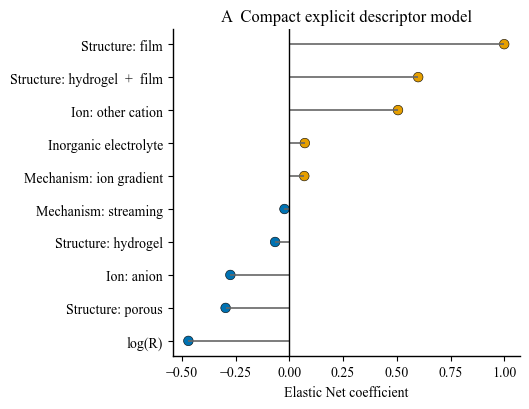

In [15]:
# Fig. 6A coefficient plot
fig, ax = plt.subplots(figsize=(5.4, 4.2))

plot_df = coef_plot_df.sort_values("coefficient")

y_pos = np.arange(len(plot_df))

colors = [
    COLORS["blue"] if c < 0 else COLORS["orange"]
    for c in plot_df["coefficient"]
]

ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=plot_df["coefficient"],
    color=COLORS["gray"],
    linewidth=1.2
)

ax.scatter(
    plot_df["coefficient"],
    y_pos,
    s=48,
    color=colors,
    edgecolor="black",
    linewidth=0.4
)

ax.axvline(0, color=COLORS["black"], linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Elastic Net coefficient")
ax.set_title("A  Compact explicit descriptor model")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

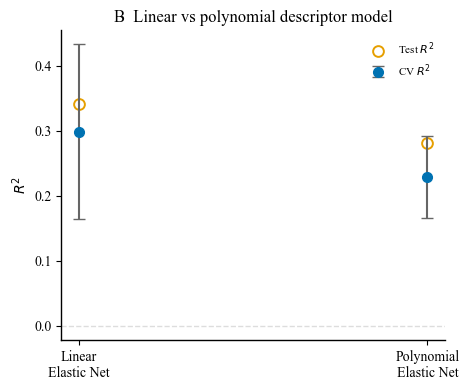

In [16]:
# Fig. 6B model comparison plot
fig, ax = plt.subplots(figsize=(4.8, 4.0))

plot_df = fig6B_df.copy()
x = np.arange(len(plot_df))

ax.errorbar(
    x,
    plot_df["cv_R2_mean"],
    yerr=plot_df["cv_R2_std"],
    fmt="o",
    markersize=7,
    capsize=4,
    color=COLORS["blue"],
    ecolor=COLORS["gray"],
    label="CV $R^2$"
)

ax.scatter(
    x,
    plot_df["test_R2"],
    s=60,
    facecolors="white",
    edgecolors=COLORS["orange"],
    linewidths=1.4,
    label="Test $R^2$"
)

ax.axhline(0, color=COLORS["light_gray"], linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(
    ["Linear\nElastic Net", "Polynomial\nElastic Net"]
)
ax.set_ylabel("$R^2$")
ax.set_title("B  Linear vs polynomial descriptor model")
ax.legend(frameon=False, fontsize=8)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
# Build virtual design helper
def most_common_value(series):
    s = series.dropna()
    if len(s) == 0:
        return np.nan
    return s.value_counts().index[0]


reference_design = {
    "structure_clean": most_common_value(df_model["structure_clean"]),
    "ion_type_clean": most_common_value(df_model["ion_type_clean"]),
    "inorganic_electrolyte_present_clean": most_common_value(df_model["inorganic_electrolyte_present_clean"]),
    "mechanism_clean": most_common_value(df_model["mechanism_clean"]),
}

print("Reference design:")
display(reference_design)


def build_virtual_df(
    log_R_values,
    structure=None,
    ion_type=None,
    inorganic_electrolyte=None,
    mechanism=None,
):
    """
    Build a virtual descriptor dataframe for prediction.
    """
    log_R_values = np.asarray(log_R_values)
    
    out = pd.DataFrame({
        "log_R": log_R_values,
        "inorganic_electrolyte_present_clean": (
            reference_design["inorganic_electrolyte_present_clean"]
            if inorganic_electrolyte is None else inorganic_electrolyte
        ),
        "structure_clean": (
            reference_design["structure_clean"]
            if structure is None else structure
        ),
        "ion_type_clean": (
            reference_design["ion_type_clean"]
            if ion_type is None else ion_type
        ),
        "mechanism_clean": (
            reference_design["mechanism_clean"]
            if mechanism is None else mechanism
        ),
    })
    
    return out[FEATURES]

Reference design:


{'structure_clean': 'porous',
 'ion_type_clean': 'proton',
 'inorganic_electrolyte_present_clean': np.int64(0),
 'mechanism_clean': 'ion_gradient'}

In [18]:
# Fig. 6C virtual design map data
# Use common structure classes for a readable heatmap
structure_counts = df_model["structure_clean"].value_counts()
structure_order = list(structure_counts.index[:5])

# Prefer interpretable ordering if these categories exist
preferred_structures = [
    "porous",
    "film",
    "hydrogel",
    "hydrogel_+_porous",
    "hydrogel+porous",
    "hydrogel_+_film",
    "hydrogel+film",
]

structure_order = [
    s for s in preferred_structures if s in set(df_model["structure_clean"])
] + [
    s for s in structure_order if s not in preferred_structures
]

structure_order = structure_order[:5]

# Use other_cation if available; otherwise use the most common ion type.
if "other_cation" in set(df_model["ion_type_clean"]):
    design_ion = "other_cation"
else:
    design_ion = reference_design["ion_type_clean"]

# Use inorganic electrolyte = 1 if available.
if 1 in set(df_model["inorganic_electrolyte_present_clean"].dropna()):
    design_inorg = 1
else:
    design_inorg = reference_design["inorganic_electrolyte_present_clean"]

logR_grid = np.linspace(-2.5, 1.5, 80)

virtual_rows = []

for structure in structure_order:
    df_v = build_virtual_df(
        log_R_values=logR_grid,
        structure=structure,
        ion_type=design_ion,
        inorganic_electrolyte=design_inorg,
    )
    
    pred = linear_model.predict(df_v)
    
    for r_value, p_value in zip(logR_grid, pred):
        virtual_rows.append({
            "structure_clean": structure,
            "ion_type_clean": design_ion,
            "inorganic_electrolyte_present_clean": design_inorg,
            "log_R": r_value,
            "predicted_log_P_est": p_value,
        })

fig6C_df = pd.DataFrame(virtual_rows)

display(fig6C_df.head())
display(fig6C_df.groupby("structure_clean")["predicted_log_P_est"].describe())

fig6C_df.to_csv(
    out_dir / "fig6C_virtual_design_map.csv",
    index=False,
    encoding="utf-8-sig"
)

,structure_clean,ion_type_clean,inorganic_electrolyte_present_clean,log_R,predicted_log_P_est
0,porous,other_cation,1,-2.500000,0.671666
1,porous,other_cation,1,-2.449367,0.654169
2,porous,other_cation,1,-2.398734,0.636673
3,porous,other_cation,1,-2.348101,0.619176
4,porous,other_cation,1,-2.297468,0.601679


,count,mean,std,min,25%,50%,75%,max
structure_clean,,,,,,,,
film,80.0,1.276032,0.406589,0.584908,0.930470,1.276032,1.621593,1.967155
hydrogel,80.0,0.210714,0.406589,-0.480409,-0.134848,0.210714,0.556275,0.901837
hydrogel_+_film,80.0,0.875990,0.406589,0.184867,0.530429,0.875990,1.221552,1.567113
hydrogel_+_porous,80.0,0.276519,0.406589,-0.414604,-0.069043,0.276519,0.622080,0.967642
porous,80.0,-0.019457,0.406589,-0.710580,-0.365019,-0.019457,0.326105,0.671666


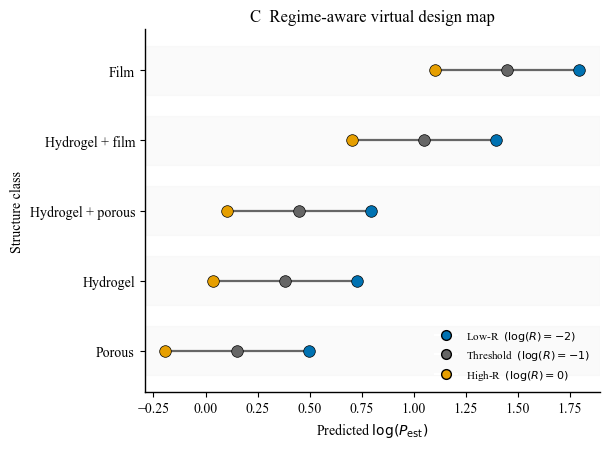

In [19]:
# ==========================================
# Fig. 6C Regime-aware virtual design map
# ==========================================

fig, ax = plt.subplots(figsize=(6.2, 4.6))

structure_label_map = {
    "porous": "Porous",
    "film": "Film",
    "hydrogel": "Hydrogel",
    "hydrogel_+_porous": "Hydrogel + porous",
    "hydrogel+porous": "Hydrogel + porous",
    "hydrogel_+_film": "Hydrogel + film",
    "hydrogel+film": "Hydrogel + film",
}

# Choose three representative resistance states
# You can change the high-R point to 1.0 if you want stronger contrast.
regime_points = {
    "Low-R": -2.0,
    "Threshold": -1.0,
    "High-R": 0.0
}

regime_colors = {
    "Low-R": COLORS["blue"],
    "Threshold": COLORS["gray"],
    "High-R": COLORS["orange"]
}

rows = []

for structure in structure_order:
    for regime_name, logR_value in regime_points.items():
        df_v = build_virtual_df(
            log_R_values=[logR_value],
            structure=structure,
            ion_type=design_ion,
            inorganic_electrolyte=design_inorg,
        )
        pred = linear_model.predict(df_v)[0]
        rows.append({
            "structure_clean": structure,
            "structure_label": structure_label_map.get(
                structure,
                structure.replace("_", " ").replace("+", " + ")
            ),
            "regime": regime_name,
            "log_R": logR_value,
            "predicted_log_P_est": pred
        })

fig6C_regime_df = pd.DataFrame(rows)

# Order structures by Low-R predicted performance (best at top)
order_df = (
    fig6C_regime_df[fig6C_regime_df["regime"] == "Low-R"]
    .sort_values("predicted_log_P_est", ascending=False)
)
ordered_structures = order_df["structure_label"].tolist()

y_positions = np.arange(len(ordered_structures))[::-1]
y_map = dict(zip(ordered_structures, y_positions))

# Light background bands for readability
for y in y_positions:
    ax.axhspan(y - 0.35, y + 0.35, color=COLORS["very_light_gray"], alpha=0.35, zorder=0)

# Draw connecting lines and points
for struct_label in ordered_structures:
    sub = fig6C_regime_df[fig6C_regime_df["structure_label"] == struct_label].copy()
    sub["regime_order"] = sub["regime"].map({"High-R": 0, "Threshold": 1, "Low-R": 2})
    sub = sub.sort_values("regime_order")
    
    y = y_map[struct_label]
    
    # connecting line
    ax.plot(
        sub["predicted_log_P_est"],
        [y] * len(sub),
        color=COLORS["gray"],
        linewidth=1.6,
        zorder=1
    )
    
    # points
    for _, row in sub.iterrows():
        ax.scatter(
            row["predicted_log_P_est"],
            y,
            s=70,
            color=regime_colors[row["regime"]],
            edgecolor="black",
            linewidth=0.5,
            zorder=2
        )

# Label y-axis
ax.set_yticks(list(y_map.values()))
ax.set_yticklabels(list(y_map.keys()))

# Axes labels
ax.set_xlabel(r"Predicted $\log(P_\mathrm{est})$")
ax.set_ylabel("Structure class")
ax.set_title("C  Regime-aware virtual design map")

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Low-R  $(\\log(R)=-2)$',
           markerfacecolor=regime_colors["Low-R"], markeredgecolor='black', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='Threshold  $(\\log(R)=-1)$',
           markerfacecolor=regime_colors["Threshold"], markeredgecolor='black', markersize=7),
    Line2D([0], [0], marker='o', color='w', label='High-R  $(\\log(R)=0)$',
           markerfacecolor=regime_colors["High-R"], markeredgecolor='black', markersize=7),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=8, loc="lower right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [20]:
# Build ranked virtual design candidates
# Candidate design space
candidate_logR_values = [-2.0, -1.0, 0.0, 1.0]

candidate_structures = structure_order

candidate_ions = [
    ion for ion in ["proton", "other_cation", "anion"]
    if ion in set(df_model["ion_type_clean"])
]

if len(candidate_ions) == 0:
    candidate_ions = list(df_model["ion_type_clean"].value_counts().index[:3])

candidate_inorg_values = [
    v for v in [0, 1]
    if v in set(df_model["inorganic_electrolyte_present_clean"].dropna())
]

if len(candidate_inorg_values) == 0:
    candidate_inorg_values = [reference_design["inorganic_electrolyte_present_clean"]]

candidate_rows = []

for structure in candidate_structures:
    for ion in candidate_ions:
        for inorg in candidate_inorg_values:
            for logR in candidate_logR_values:
                df_v = build_virtual_df(
                    log_R_values=[logR],
                    structure=structure,
                    ion_type=ion,
                    inorganic_electrolyte=inorg,
                )
                
                pred = linear_model.predict(df_v)[0]
                
                candidate_rows.append({
                    "structure_clean": structure,
                    "ion_type_clean": ion,
                    "inorganic_electrolyte_present_clean": inorg,
                    "log_R": logR,
                    "R_regime": "low_R" if logR <= -1.0 else "high_R",
                    "predicted_log_P_est": pred,
                })

fig6D_df = pd.DataFrame(candidate_rows)

fig6D_df = fig6D_df.sort_values(
    "predicted_log_P_est",
    ascending=False
).reset_index(drop=True)

display(fig6D_df.head(15))

fig6D_df.to_csv(
    out_dir / "fig6D_virtual_design_candidates_all.csv",
    index=False,
    encoding="utf-8-sig"
)

fig6D_top_df = fig6D_df.head(10).copy()

fig6D_top_df.to_csv(
    out_dir / "fig6D_top_virtual_design_candidates.csv",
    index=False,
    encoding="utf-8-sig"
)

,structure_clean,ion_type_clean,inorganic_electrolyte_present_clean,log_R,R_regime,predicted_log_P_est
0,film,other_cation,1,-2.0,low_R,1.794374
1,film,other_cation,0,-2.0,low_R,1.644268
2,film,other_cation,1,-1.0,low_R,1.448812
3,hydrogel_+_film,other_cation,1,-2.0,low_R,1.394333
4,film,other_cation,0,-1.0,low_R,1.298706
5,film,proton,1,-2.0,low_R,1.288732
6,hydrogel_+_film,other_cation,0,-2.0,low_R,1.244226
7,film,proton,0,-2.0,low_R,1.138626
8,film,other_cation,1,0.0,high_R,1.103251
9,hydrogel_+_film,other_cation,1,-1.0,low_R,1.048771


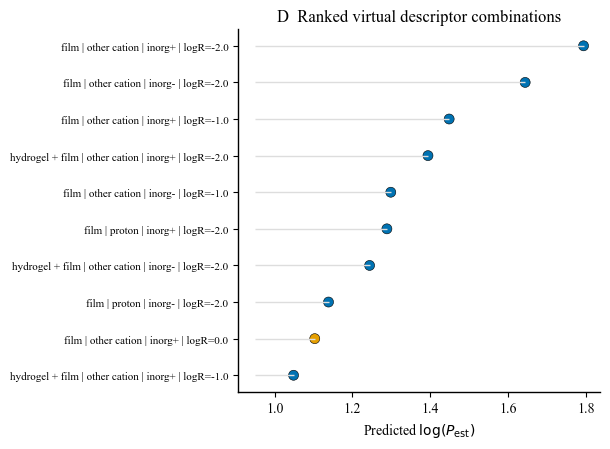

In [21]:
# Fig. 6D ranked virtual design plot
plot_df = fig6D_top_df.copy()

def candidate_label(row):
    inorg_label = "inorg+" if row["inorganic_electrolyte_present_clean"] == 1 else "inorg-"
    return (
        f"{row['structure_clean'].replace('_', ' ')} | "
        f"{row['ion_type_clean'].replace('_', ' ')} | "
        f"{inorg_label} | "
        f"logR={row['log_R']:.1f}"
    )

plot_df["label"] = plot_df.apply(candidate_label, axis=1)

plot_df = plot_df.sort_values("predicted_log_P_est", ascending=True)

colors = [
    COLORS["blue"] if reg == "low_R" else COLORS["orange"]
    for reg in plot_df["R_regime"]
]

fig, ax = plt.subplots(figsize=(6.2, 4.6))

y_pos = np.arange(len(plot_df))

ax.hlines(
    y=y_pos,
    xmin=plot_df["predicted_log_P_est"].min() - 0.1,
    xmax=plot_df["predicted_log_P_est"],
    color=COLORS["light_gray"],
    linewidth=1.0
)

ax.scatter(
    plot_df["predicted_log_P_est"],
    y_pos,
    s=52,
    color=colors,
    edgecolor="black",
    linewidth=0.4
)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"], fontsize=8)

ax.set_xlabel(r"Predicted $\log(P_\mathrm{est})$")
ax.set_title("D  Ranked virtual descriptor combinations")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

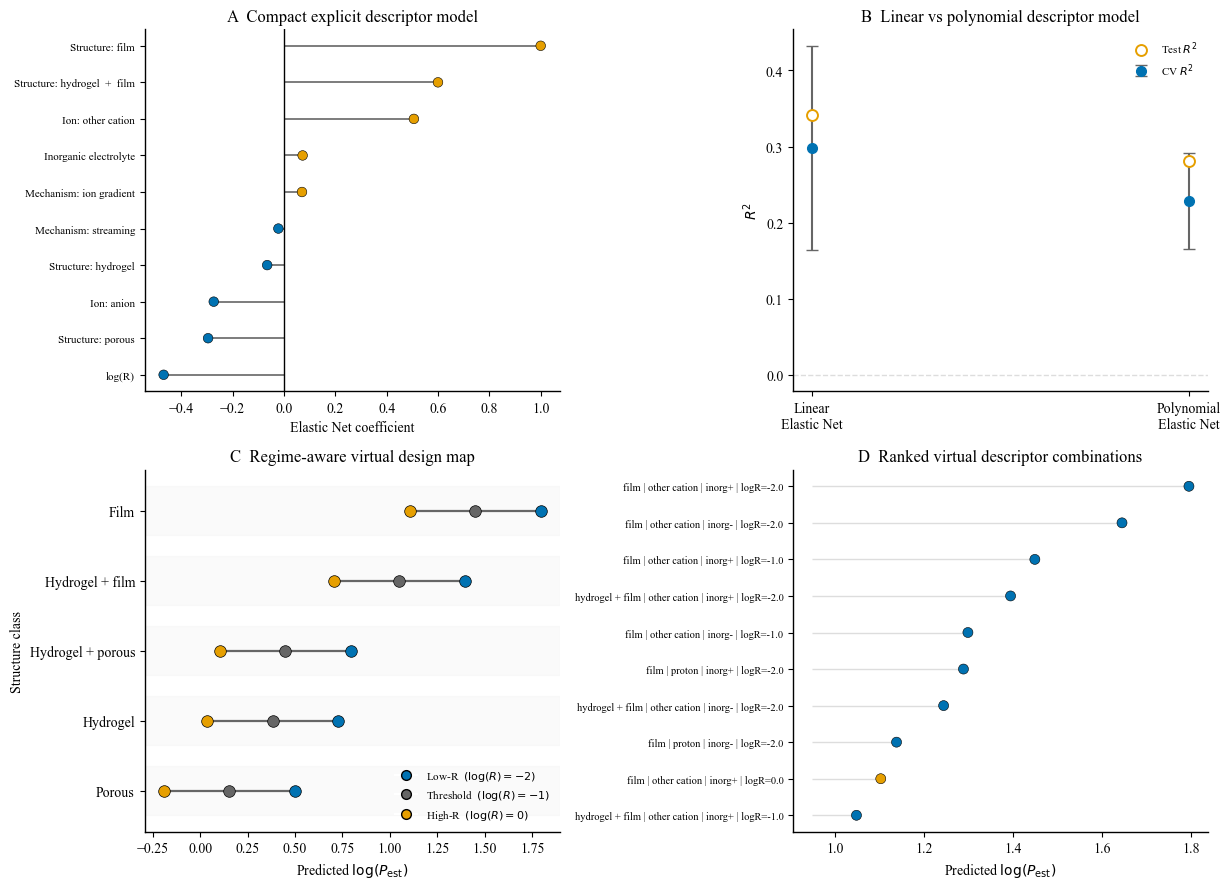

In [22]:
# ==========================================
# Combined Figure 6
# ==========================================

from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(12.4, 9.0))

# =========================
# A. Compact explicit descriptor model
# =========================
ax = axes[0, 0]

plot_a = coef_plot_df.sort_values("coefficient").copy()
y_pos = np.arange(len(plot_a))

colors_a = [
    COLORS["blue"] if c < 0 else COLORS["orange"]
    for c in plot_a["coefficient"]
]

ax.hlines(
    y=y_pos,
    xmin=0,
    xmax=plot_a["coefficient"],
    color=COLORS["gray"],
    linewidth=1.2
)

ax.scatter(
    plot_a["coefficient"],
    y_pos,
    s=48,
    color=colors_a,
    edgecolor="black",
    linewidth=0.4,
    zorder=3
)

ax.axvline(0, color=COLORS["black"], linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_a["label"], fontsize=8)
ax.set_xlabel("Elastic Net coefficient")
ax.set_title("A  Compact explicit descriptor model")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# B. Linear vs polynomial descriptor model
# =========================
ax = axes[0, 1]

plot_b = fig6B_df.copy()
x = np.arange(len(plot_b))

# CV R2 with error bars
ax.errorbar(
    x,
    plot_b["cv_R2_mean"],
    yerr=plot_b["cv_R2_std"],
    fmt="o",
    markersize=7,
    capsize=4,
    color=COLORS["blue"],
    ecolor=COLORS["gray"],
    label="CV $R^2$"
)

# Test R2
ax.scatter(
    x,
    plot_b["test_R2"],
    s=62,
    facecolors="white",
    edgecolors=COLORS["orange"],
    linewidths=1.4,
    label="Test $R^2$",
    zorder=3
)

ax.axhline(0, color=COLORS["light_gray"], linestyle="--", linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(["Linear\nElastic Net", "Polynomial\nElastic Net"])
ax.set_ylabel("$R^2$")
ax.set_title("B  Linear vs polynomial descriptor model")
ax.legend(frameon=False, fontsize=8, loc="upper right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# C. Regime-aware virtual design map
# =========================
ax = axes[1, 0]

# ---- label map ----
structure_label_map = {
    "porous": "Porous",
    "film": "Film",
    "hydrogel": "Hydrogel",
    "hydrogel_+_porous": "Hydrogel + porous",
    "hydrogel+porous": "Hydrogel + porous",
    "hydrogel_+_film": "Hydrogel + film",
    "hydrogel+film": "Hydrogel + film",
}

# ---- three representative resistance states ----
regime_points = {
    "Low-R": -2.0,
    "Threshold": -1.0,
    "High-R": 0.0
}

regime_colors = {
    "Low-R": COLORS["blue"],
    "Threshold": COLORS["gray"],
    "High-R": COLORS["orange"]
}

rows = []

for structure in structure_order:
    for regime_name, logR_value in regime_points.items():
        df_v = build_virtual_df(
            log_R_values=[logR_value],
            structure=structure,
            ion_type=design_ion,
            inorganic_electrolyte=design_inorg,
        )
        pred = linear_model.predict(df_v)[0]
        rows.append({
            "structure_clean": structure,
            "structure_label": structure_label_map.get(
                structure,
                structure.replace("_", " ").replace("+", " + ")
            ),
            "regime": regime_name,
            "log_R": logR_value,
            "predicted_log_P_est": pred
        })

fig6C_regime_df = pd.DataFrame(rows)

# order structures by Low-R predicted performance
order_df = (
    fig6C_regime_df[fig6C_regime_df["regime"] == "Low-R"]
    .sort_values("predicted_log_P_est", ascending=False)
)
ordered_structures = order_df["structure_label"].tolist()

y_positions = np.arange(len(ordered_structures))[::-1]
y_map = dict(zip(ordered_structures, y_positions))

# background bands
for y in y_positions:
    ax.axhspan(
        y - 0.35, y + 0.35,
        color=COLORS["very_light_gray"],
        alpha=0.35,
        zorder=0
    )

# draw lines and points
for struct_label in ordered_structures:
    sub = fig6C_regime_df[fig6C_regime_df["structure_label"] == struct_label].copy()
    sub["regime_order"] = sub["regime"].map({"High-R": 0, "Threshold": 1, "Low-R": 2})
    sub = sub.sort_values("regime_order")

    y = y_map[struct_label]

    ax.plot(
        sub["predicted_log_P_est"],
        [y] * len(sub),
        color=COLORS["gray"],
        linewidth=1.6,
        zorder=1
    )

    for _, row in sub.iterrows():
        ax.scatter(
            row["predicted_log_P_est"],
            y,
            s=70,
            color=regime_colors[row["regime"]],
            edgecolor="black",
            linewidth=0.5,
            zorder=2
        )

ax.set_yticks(list(y_map.values()))
ax.set_yticklabels(list(y_map.keys()))
ax.set_xlabel(r"Predicted $\log(P_{\mathrm{est}})$")
ax.set_ylabel("Structure class")
ax.set_title("C  Regime-aware virtual design map")

legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           label='Low-R  $(\\log(R)=-2)$',
           markerfacecolor=regime_colors["Low-R"],
           markeredgecolor='black', markersize=7),
    Line2D([0], [0], marker='o', color='w',
           label='Threshold  $(\\log(R)=-1)$',
           markerfacecolor=regime_colors["Threshold"],
           markeredgecolor='black', markersize=7),
    Line2D([0], [0], marker='o', color='w',
           label='High-R  $(\\log(R)=0)$',
           markerfacecolor=regime_colors["High-R"],
           markeredgecolor='black', markersize=7),
]

ax.legend(handles=legend_elements, frameon=False, fontsize=8, loc="lower right")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# D. Ranked virtual descriptor combinations
# =========================
ax = axes[1, 1]

plot_d = fig6D_top_df.copy()

def candidate_label(row):
    inorg_label = "inorg+" if row["inorganic_electrolyte_present_clean"] == 1 else "inorg-"
    return (
        f"{row['structure_clean'].replace('_', ' ')} | "
        f"{row['ion_type_clean'].replace('_', ' ')} | "
        f"{inorg_label} | "
        f"logR={row['log_R']:.1f}"
    )

plot_d["label"] = plot_d.apply(candidate_label, axis=1)
plot_d = plot_d.sort_values("predicted_log_P_est", ascending=True)

colors_d = [
    COLORS["blue"] if reg == "low_R" else COLORS["orange"]
    for reg in plot_d["R_regime"]
]

y_pos = np.arange(len(plot_d))

ax.hlines(
    y=y_pos,
    xmin=plot_d["predicted_log_P_est"].min() - 0.1,
    xmax=plot_d["predicted_log_P_est"],
    color=COLORS["light_gray"],
    linewidth=1.0
)

ax.scatter(
    plot_d["predicted_log_P_est"],
    y_pos,
    s=52,
    color=colors_d,
    edgecolor="black",
    linewidth=0.4,
    zorder=3
)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_d["label"], fontsize=7.5)

ax.set_xlabel(r"Predicted $\log(P_{\mathrm{est}})$")
ax.set_title("D  Ranked virtual descriptor combinations")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# =========================
# Final layout and export
# =========================
plt.tight_layout()

fig.savefig(out_dir / "figure6_virtual_design_draft_v2.png", dpi=300, bbox_inches="tight")
fig.savefig(out_dir / "figure6_virtual_design_draft_v2.pdf", bbox_inches="tight")

plt.show()

In [23]:
# Prediction output for test set
fig6_test_pred_df = pd.DataFrame({
    "observed_log_P_est": y_test.values,
    "linear_predicted_log_P_est": y_test_pred_linear,
    "polynomial_predicted_log_P_est": y_test_pred_poly,
})

fig6_test_pred_df.to_csv(
    out_dir / "fig6_test_set_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Exported files:")
for f in sorted(out_dir.glob("*")):
    print(f.name)

Exported files:
fig6_test_set_predictions.csv
fig6A_linear_descriptor_coefficients_plot.csv
fig6A_linear_descriptor_coefficients_raw.csv
fig6B_linear_vs_polynomial_model_comparison.csv
fig6C_virtual_design_map.csv
fig6D_top_virtual_design_candidates.csv
fig6D_virtual_design_candidates_all.csv
figure6_virtual_design_draft.pdf
figure6_virtual_design_draft.png
figure6_virtual_design_draft_v2.pdf
figure6_virtual_design_draft_v2.png


## Figure 6 summary

Figure 6 converts descriptor-level machine-learning results into design logic.

- Fig. 6A shows the coefficients of a compact Elastic Net descriptor model.
- Fig. 6B compares linear and polynomial descriptor models.
- Fig. 6C shows a virtual design map where predicted performance is evaluated across resistance and structure descriptors.
- Fig. 6D ranks virtual descriptor combinations.

The virtual design results should be interpreted as descriptor-guided screening, not as direct prediction of experimentally optimized device recipes.

In [24]:
display(coef_plot_df)
display(fig6B_df)
display(fig6C_df.head())
display(fig6D_top_df)

,feature,coefficient,abs_coefficient,label
0,cat__structure_clean_film,0.999513,0.999513,Structure: film
1,cat__structure_clean_hydrogel_+_film,0.599472,0.599472,Structure: hydrogel + film
2,cat__ion_type_clean_other_cation,0.505642,0.505642,Ion: other cation
3,num__log_R,-0.469094,0.469094,log(R)
4,cat__structure_clean_porous,-0.295976,0.295976,Structure: porous
5,cat__ion_type_clean_anion,-0.273914,0.273914,Ion: anion
6,num__inorganic_electrolyte_present_clean,0.072311,0.072311,Inorganic electrolyte
7,cat__mechanism_clean_ion_gradient,0.069794,0.069794,Mechanism: ion gradient
8,cat__structure_clean_hydrogel,-0.065805,0.065805,Structure: hydrogel
9,cat__mechanism_clean_streaming,-0.022199,0.022199,Mechanism: streaming


,model,train_R2,test_R2,test_RMSE,test_MAE,cv_R2_mean,cv_R2_std,cv_RMSE_mean,cv_RMSE_std,cv_MAE_mean,cv_MAE_std
0,Linear Elastic Net descriptor,0.447677,0.341504,0.900899,0.684797,0.298469,0.133919,1.034126,0.095595,0.804468,0.068022
1,Polynomial Elastic Net descriptor,0.440545,0.280680,0.941588,0.751510,0.228305,0.062941,1.094372,0.129098,0.865327,0.102349


,structure_clean,ion_type_clean,inorganic_electrolyte_present_clean,log_R,predicted_log_P_est
0,porous,other_cation,1,-2.500000,0.671666
1,porous,other_cation,1,-2.449367,0.654169
2,porous,other_cation,1,-2.398734,0.636673
3,porous,other_cation,1,-2.348101,0.619176
4,porous,other_cation,1,-2.297468,0.601679


,structure_clean,ion_type_clean,inorganic_electrolyte_present_clean,log_R,R_regime,predicted_log_P_est
0,film,other_cation,1,-2.0,low_R,1.794374
1,film,other_cation,0,-2.0,low_R,1.644268
2,film,other_cation,1,-1.0,low_R,1.448812
3,hydrogel_+_film,other_cation,1,-2.0,low_R,1.394333
4,film,other_cation,0,-1.0,low_R,1.298706
5,film,proton,1,-2.0,low_R,1.288732
6,hydrogel_+_film,other_cation,0,-2.0,low_R,1.244226
7,film,proton,0,-2.0,low_R,1.138626
8,film,other_cation,1,0.0,high_R,1.103251
9,hydrogel_+_film,other_cation,1,-1.0,low_R,1.048771


In [25]:
# R1C6 production integration: load the validated sparse-hybrid-excluded
# explicit descriptor model rather than refitting it in this notebook.
# The literature-derived hybrid labels remain in the canonical dataset, but
# cannot generate coefficients or virtual design rules.
r1c6_dir = Path("../results/revision/R1C6")

fig6A_raw = pd.read_csv(r1c6_dir / "explicit_descriptor_model_sensitivity.csv", encoding="utf-8-sig")
fig6A_raw.to_csv(out_dir / "fig6A_linear_descriptor_coefficients_raw.csv", index=False, encoding="utf-8-sig")

def clean_r1c6_coefficient_label(name):
    label = str(name).replace("num__", "").replace("cat__", "")
    label = label.replace("log_R", "log(R)")
    label = label.replace("inorganic_electrolyte_present_clean", "Inorganic electrolyte")
    label = label.replace("structure_clean_", "Structure: ")
    label = label.replace("ion_type_clean_", "Ion: ")
    label = label.replace("mechanism_clean_", "Mechanism: ")
    return label.replace("_", " ")

fig6A_plot = fig6A_raw.loc[fig6A_raw["abs_coefficient"] > 1e-8].copy()
fig6A_plot["label"] = fig6A_plot["feature"].map(clean_r1c6_coefficient_label)
fig6A_plot.to_csv(out_dir / "fig6A_linear_descriptor_coefficients_plot.csv", index=False, encoding="utf-8-sig")

fig6B_r1c6 = pd.read_csv(r1c6_dir / "explicit_descriptor_model_performance_sensitivity.csv", encoding="utf-8-sig")
fig6B_r1c6.to_csv(out_dir / "fig6B_linear_vs_polynomial_model_comparison.csv", index=False, encoding="utf-8-sig")

fig6D_all = pd.read_csv(r1c6_dir / "virtual_design_sensitivity.csv", encoding="utf-8-sig")
allowed_structures = {"porous", "film", "hydrogel"}
if not set(fig6D_all["structure_clean"]).issubset(allowed_structures):
    raise ValueError("R1C6 virtual-design source contains a sparse hybrid structure.")
fig6D_all.to_csv(out_dir / "fig6D_virtual_design_candidates_all.csv", index=False, encoding="utf-8-sig")
fig6D_all.head(10).to_csv(out_dir / "fig6D_top_virtual_design_candidates.csv", index=False, encoding="utf-8-sig")

# Figure 6C keeps the established other-cation/inorganic-electrolyte reference
# condition at the three displayed resistance states.
fig6C_regime_df = fig6D_all.loc[
    (fig6D_all["ion_type_clean"] == "other_cation")
    & (fig6D_all["inorganic_electrolyte_present_clean"] == 1)
    & (fig6D_all["log_R"].isin([-2.0, -1.0, 0.0]))
].copy()
fig6C_regime_df["structure_label"] = fig6C_regime_df["structure_clean"].str.replace("_", " ", regex=False).str.title()
fig6C_regime_df["regime"] = fig6C_regime_df["log_R"].map({-2.0: "Low-R", -1.0: "Threshold", 0.0: "High-R"})
fig6C_regime_df = fig6C_regime_df[["structure_clean", "structure_label", "regime", "log_R", "predicted_log_P_est"]]
fig6C_regime_df = fig6C_regime_df.sort_values(["structure_clean", "log_R"]).reset_index(drop=True)
fig6C_regime_df.to_csv(out_dir / "fig6C_regime_aware_virtual_design.csv", index=False, encoding="utf-8-sig")
fig6C_regime_df.to_csv(out_dir / "fig6C_virtual_design_map.csv", index=False, encoding="utf-8-sig")

print("Integrated validated R1C6 Figure 6 sources from:", r1c6_dir)

..\results\figure6_virtual_design\fig6C_regime_aware_virtual_design.csv


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

fig6_dir = Path("../results/figure6_virtual_design")
final_dir = fig6_dir / "final_panels"
final_dir.mkdir(parents=True, exist_ok=True)

print("Figure 6 result folder:", fig6_dir.resolve())
print("Final panel output folder:", final_dir.resolve())

COLORS_FINAL = {
    "black": "#000000",
    "dark_gray": "#4D4D4D",
    "gray": "#8C8C8C",
    "light_gray": "#C7C7C7",
    "very_light_gray": "#EFEFEF",

    "blue": "#0072B2",
    "sky_blue": "#56B4E9",
    "green": "#009E73",
    "orange": "#E69F00",
    "vermillion": "#D55E00",
    "purple": "#CC79A7",
    "yellow": "#F0E442",
}

SEMANTIC_FINAL = {
    # Same meaning as Figure 3
    "descriptor": "#009E73",
    "descriptor_fill": "#BFD8CF",

    "loss": "#D55E00",
    "loss_fill": "#E7D3BE",

    "neutral": "#8C8C8C",
    "neutral_light": "#BDBDBD",
    "neutral_fill": "#EFEFEF",

    "reference": "#D0D0D0",
    "highlight": "#000000",

    # Regime colors, same as Figure 4/5
    "low_R": "#009E73",
    "low_R_fill": "#BFD8CF",
    "threshold": "#8C8C8C",
    "high_R": "#D55E00",
    "high_R_fill": "#E7D3BE",
}


def set_final_style():
    mpl.rcParams.update({
        "font.family": "Arial",
        "font.size": 8.5,
        "font.weight": "normal",

        "mathtext.fontset": "custom",
        "mathtext.rm": "Arial",
        "mathtext.it": "Arial:italic",
        "mathtext.bf": "Arial:bold",

        "axes.linewidth": 1.0,
        "axes.labelsize": 9.5,
        "axes.titlesize": 10,
        "axes.labelweight": "normal",
        "axes.titleweight": "normal",

        "xtick.labelsize": 8.0,
        "ytick.labelsize": 8.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,

        "lines.linewidth": 1.2,
        "lines.markersize": 4,

        "legend.fontsize": 7.8,
        "legend.frameon": False,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",

        "savefig.dpi": 600,
        "figure.dpi": 150,
        "axes.grid": False,
    })


def format_final_ax(ax, mirror=True):
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color(COLORS_FINAL["black"])

    ax.spines["top"].set_visible(mirror)
    ax.spines["right"].set_visible(mirror)

    ax.tick_params(
        direction="out",
        width=1.0,
        length=4,
        color=COLORS_FINAL["black"],
        top=False,
        right=False,
    )

    return ax


def save_final_panel(fig, name):
    pdf_path = final_dir / f"{name}.pdf"
    svg_path = final_dir / f"{name}.svg"
    png_path = final_dir / f"{name}.png"

    # Fixed canvas export keeps A/B/C/D external dimensions identical.
    fig.savefig(pdf_path)
    fig.savefig(svg_path)
    fig.savefig(png_path, dpi=600)

    print("Saved:")
    print(" -", pdf_path.name)
    print(" -", svg_path.name)
    print(" -", png_path.name)


set_final_style()

Figure 6 result folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure6_virtual_design
Final panel output folder: C:\Users\wenlu\OneDrive\books_coding\Python_Projects\hydrovoltaic-ml\results\figure6_virtual_design\final_panels


In [2]:
fig6A_path = fig6_dir / "fig6A_linear_descriptor_coefficients_plot.csv"
fig6B_path = fig6_dir / "fig6B_linear_vs_polynomial_model_comparison.csv"
fig6C_path = fig6_dir / "fig6C_regime_aware_virtual_design.csv"
fig6D_path = fig6_dir / "fig6D_top_virtual_design_candidates.csv"

for p in [fig6A_path, fig6B_path, fig6C_path, fig6D_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

fig6A = pd.read_csv(fig6A_path, encoding="utf-8-sig")
fig6B = pd.read_csv(fig6B_path, encoding="utf-8-sig")
fig6C = pd.read_csv(fig6C_path, encoding="utf-8-sig")
fig6D = pd.read_csv(fig6D_path, encoding="utf-8-sig")

print("Loaded:")
print(" -", fig6A_path.name, fig6A.shape)
print(" -", fig6B_path.name, fig6B.shape)
print(" -", fig6C_path.name, fig6C.shape)
print(" -", fig6D_path.name, fig6D.shape)

display(fig6A)
display(fig6B)
display(fig6C.head())
display(fig6D.head())

Loaded:
 - fig6A_linear_descriptor_coefficients_plot.csv (10, 4)
 - fig6B_linear_vs_polynomial_model_comparison.csv (2, 11)
 - fig6C_regime_aware_virtual_design.csv (15, 5)
 - fig6D_top_virtual_design_candidates.csv (10, 6)


,feature,coefficient,abs_coefficient,label
0,cat__structure_clean_film,0.999513,0.999513,Structure: film
1,cat__structure_clean_hydrogel_+_film,0.599472,0.599472,Structure: hydrogel + film
2,cat__ion_type_clean_other_cation,0.505642,0.505642,Ion: other cation
3,num__log_R,-0.469094,0.469094,log(R)
4,cat__structure_clean_porous,-0.295976,0.295976,Structure: porous
5,cat__ion_type_clean_anion,-0.273914,0.273914,Ion: anion
6,num__inorganic_electrolyte_present_clean,0.072311,0.072311,Inorganic electrolyte
7,cat__mechanism_clean_ion_gradient,0.069794,0.069794,Mechanism: ion gradient
8,cat__structure_clean_hydrogel,-0.065805,0.065805,Structure: hydrogel
9,cat__mechanism_clean_streaming,-0.022199,0.022199,Mechanism: streaming


,model,train_R2,test_R2,test_RMSE,test_MAE,cv_R2_mean,cv_R2_std,cv_RMSE_mean,cv_RMSE_std,cv_MAE_mean,cv_MAE_std
0,Linear Elastic Net descriptor,0.447677,0.341504,0.900899,0.684797,0.298469,0.133919,1.034126,0.095595,0.804468,0.068022
1,Polynomial Elastic Net descriptor,0.440545,0.280680,0.941588,0.751510,0.228305,0.062941,1.094372,0.129098,0.865327,0.102349


,structure_clean,structure_label,regime,log_R,predicted_log_P_est
0,porous,Porous,Low-R,-2.0,0.498885
1,porous,Porous,Threshold,-1.0,0.153324
2,porous,Porous,High-R,0.0,-0.192238
3,film,Film,Low-R,-2.0,1.794374
4,film,Film,Threshold,-1.0,1.448812


,structure_clean,ion_type_clean,inorganic_electrolyte_present_clean,log_R,R_regime,predicted_log_P_est
0,film,other_cation,1,-2.0,low_R,1.794374
1,film,other_cation,0,-2.0,low_R,1.644268
2,film,other_cation,1,-1.0,low_R,1.448812
3,hydrogel_+_film,other_cation,1,-2.0,low_R,1.394333
4,film,other_cation,0,-1.0,low_R,1.298706


Saved:
 - fig6A_final_explicit_descriptor_model.pdf
 - fig6A_final_explicit_descriptor_model.svg
 - fig6A_final_explicit_descriptor_model.png


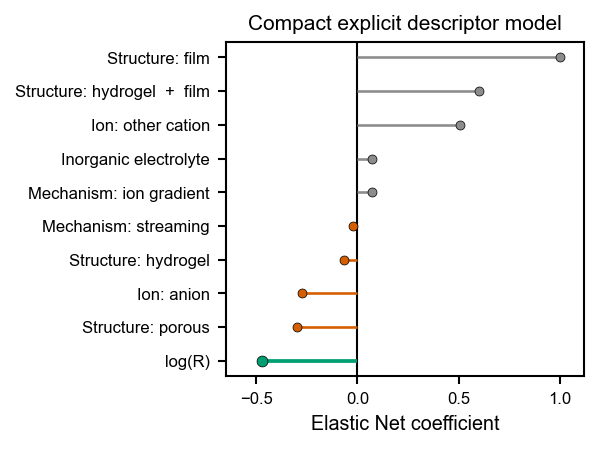

In [3]:
# =========================
# Final Fig. 6A
# Compact explicit descriptor model
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(5.15, 3.85))

plot_a = fig6A.copy()

# Sort by coefficient value for a clean negative-to-positive layout
plot_a = plot_a.sort_values("coefficient", ascending=True).reset_index(drop=True)

y = np.arange(len(plot_a))

for i, row in enumerate(plot_a.itertuples()):
    label = str(row.label)
    coef = float(row.coefficient)

    # Color logic consistent with Figure 3
    if label == "log(R)":
        color = SEMANTIC_FINAL["descriptor"]      # key descriptor
        lw = 1.8
        ms = 5.2
    elif coef < 0:
        color = SEMANTIC_FINAL["loss"]            # negative contribution
        lw = 1.25
        ms = 4.3
    else:
        color = SEMANTIC_FINAL["neutral"]         # other positive descriptors
        lw = 1.25
        ms = 4.3

    ax.hlines(
        y=i,
        xmin=0,
        xmax=coef,
        linewidth=lw,
        color=color,
        zorder=2,
    )

    ax.plot(
        coef,
        i,
        "o",
        markersize=ms,
        color=color,
        markeredgecolor=COLORS_FINAL["black"],
        markeredgewidth=0.35,
        zorder=3,
    )

ax.axvline(
    0,
    linestyle="-",
    linewidth=1.0,
    color=COLORS_FINAL["black"],
    zorder=0,
)

ax.set_yticks(y)
ax.set_yticklabels(plot_a["label"])

ax.set_xlabel("Elastic Net coefficient")
ax.set_title("Compact explicit descriptor model")

x_min = min(plot_a["coefficient"].min() - 0.12, -0.65)
x_max = max(plot_a["coefficient"].max() + 0.12, 1.10)
ax.set_xlim(x_min, x_max)

format_final_ax(ax, mirror=True)

plt.tight_layout()

save_final_panel(fig, "fig6A_final_explicit_descriptor_model")

plt.show()

Saved:
 - fig6B_final_linear_vs_polynomial_descriptor_model.pdf
 - fig6B_final_linear_vs_polynomial_descriptor_model.svg
 - fig6B_final_linear_vs_polynomial_descriptor_model.png


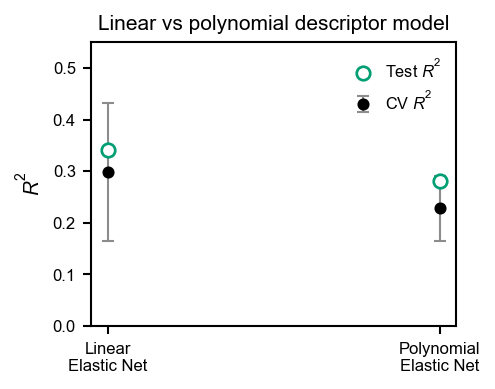

In [4]:
# =========================
# Final Fig. 6B
# Linear vs polynomial descriptor model
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(5.15, 3.85))

plot_b = fig6B.copy()

# Short labels
plot_b["plot_label"] = (
    plot_b["model"]
    .str.replace(" descriptor", "", regex=False)
    .str.replace("Linear Elastic Net", "Linear\nElastic Net", regex=False)
    .str.replace("Polynomial Elastic Net", "Polynomial\nElastic Net", regex=False)
)

x = np.array([0.0, 0.6])

# CV R2 with error bars: neutral black/gray
ax.errorbar(
    x,
    plot_b["cv_R2_mean"],
    yerr=plot_b["cv_R2_std"],
    fmt="o",
    color=COLORS_FINAL["black"],
    ecolor=COLORS_FINAL["gray"],
    elinewidth=1.0,
    capsize=3,
    markersize=4.8,
    markerfacecolor=COLORS_FINAL["black"],
    markeredgecolor=COLORS_FINAL["black"],
    label=r"CV $R^2$",
    zorder=3,
)

# Test R2: green open marker
ax.scatter(
    x,
    plot_b["test_R2"],
    s=42,
    facecolors="white",
    edgecolors=SEMANTIC_FINAL["descriptor"],
    linewidths=1.3,
    label=r"Test $R^2$",
    zorder=4,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.0,
    color=SEMANTIC_FINAL["reference"],
    zorder=0,
)

ax.set_xticks(x)
ax.set_xticklabels(plot_b["plot_label"])

ax.set_ylabel(r"$R^2$")
ax.set_title("Linear vs polynomial descriptor model")
ax.set_ylim(0, 0.55)
ax.set_xlim(-0.18, 0.78)

format_final_ax(ax, mirror=True)

ax.legend(
    loc="upper right",
    frameon=False,
    handlelength=1.2,
)

plt.tight_layout()

save_final_panel(fig, "fig6B_final_linear_vs_polynomial_descriptor_model")

plt.show()

Saved:
 - fig6C_final_regime_aware_virtual_design_map.pdf
 - fig6C_final_regime_aware_virtual_design_map.svg
 - fig6C_final_regime_aware_virtual_design_map.png


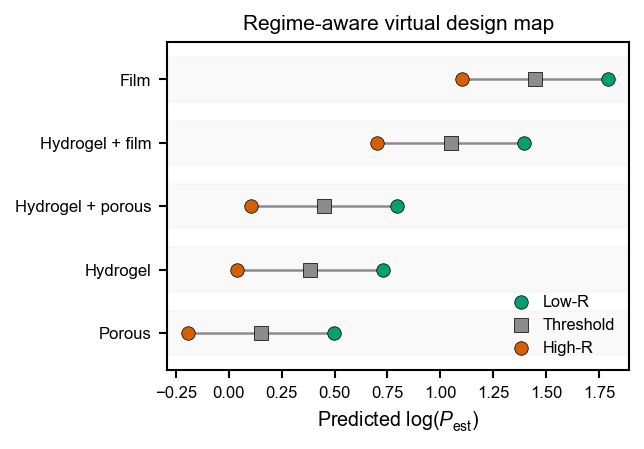

In [5]:
# =========================
# Final Fig. 6C
# Regime-aware virtual design map
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(5.15, 3.85))

plot_c = fig6C.copy()

# Expected columns:
# structure_clean, structure_label, regime, log_R, predicted_log_P_est

# Robust structure label
if "structure_label" not in plot_c.columns:
    plot_c["structure_label"] = (
        plot_c["structure_clean"]
        .astype(str)
        .str.replace("_", " ", regex=False)
        .str.replace("+", " + ", regex=False)
        .str.title()
    )

# Regime order and colors
regime_order = ["High-R", "Threshold", "Low-R"]

regime_color = {
    "Low-R": SEMANTIC_FINAL["low_R"],
    "Threshold": SEMANTIC_FINAL["neutral"],
    "High-R": SEMANTIC_FINAL["high_R"],
}

regime_marker = {
    "Low-R": "o",
    "Threshold": "s",
    "High-R": "o",
}

# Order structures by Low-R predicted performance
low_r_df = (
    plot_c[plot_c["regime"] == "Low-R"]
    .sort_values("predicted_log_P_est", ascending=False)
)

ordered_structures = low_r_df["structure_label"].tolist()

# Fallback if regime labels are different or Low-R not found
if len(ordered_structures) == 0:
    ordered_structures = (
        plot_c
        .groupby("structure_label")["predicted_log_P_est"]
        .max()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

y_pos = np.arange(len(ordered_structures))[::-1]
y_map = dict(zip(ordered_structures, y_pos))

# Light background bands
for y in y_pos:
    ax.axhspan(
        y - 0.35,
        y + 0.35,
        color=COLORS_FINAL["very_light_gray"],
        alpha=0.35,
        zorder=0,
    )

# Draw connecting line and regime points
for struct_label in ordered_structures:
    sub = plot_c[plot_c["structure_label"] == struct_label].copy()

    sub["regime_order"] = sub["regime"].map({
        "High-R": 0,
        "Threshold": 1,
        "Low-R": 2,
    })

    sub = sub.sort_values("regime_order")

    y_current = y_map[struct_label]

    ax.plot(
        sub["predicted_log_P_est"],
        [y_current] * len(sub),
        color=COLORS_FINAL["gray"],
        linewidth=1.2,
        zorder=1,
    )

    for row in sub.itertuples():
        regime = row.regime

        ax.scatter(
            row.predicted_log_P_est,
            y_current,
            s=42,
            marker=regime_marker.get(regime, "o"),
            color=regime_color.get(regime, COLORS_FINAL["gray"]),
            edgecolor=COLORS_FINAL["black"],
            linewidth=0.35,
            zorder=3,
            label=regime if struct_label == ordered_structures[0] else None,
        )

ax.set_yticks(y_pos)
ax.set_yticklabels(ordered_structures)

ax.set_xlabel(r"Predicted $\log(P_{\mathrm{est}})$")
ax.set_title("Regime-aware virtual design map")

format_final_ax(ax, mirror=True)

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
dedup = dict(zip(labels, handles))

# Order legend manually
legend_order = ["Low-R", "Threshold", "High-R"]
handles_ordered = [dedup[k] for k in legend_order if k in dedup]
labels_ordered = [k for k in legend_order if k in dedup]

ax.legend(
    handles_ordered,
    labels_ordered,
    loc="lower right",
    frameon=False,
    handlelength=1.0,
)

plt.tight_layout()

save_final_panel(fig, "fig6C_final_regime_aware_virtual_design_map")

plt.show()

Saved:
 - fig6D_final_ranked_virtual_descriptor_combinations.pdf
 - fig6D_final_ranked_virtual_descriptor_combinations.svg
 - fig6D_final_ranked_virtual_descriptor_combinations.png


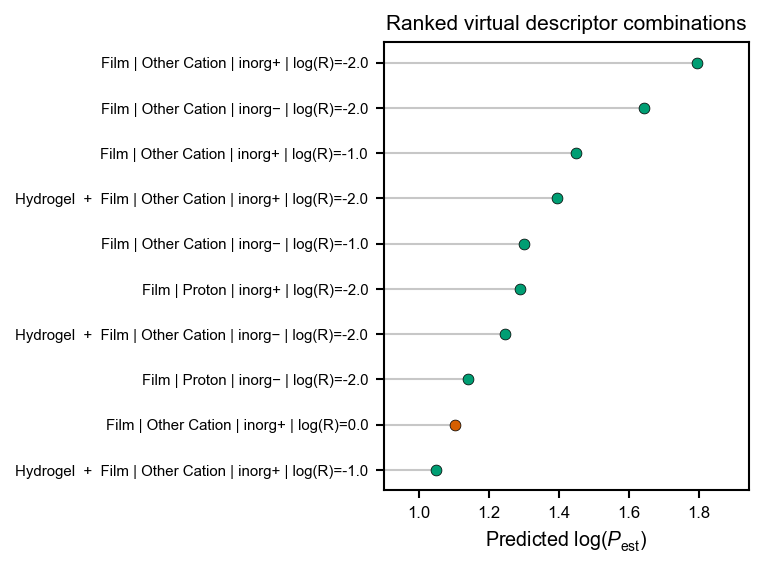

In [6]:
# =========================
# Final Fig. 6D
# Ranked virtual descriptor combinations
# =========================

set_final_style()

fig, ax = plt.subplots(figsize=(5.15, 3.85))

plot_d = fig6D.copy()

# Keep top 10 if the file contains more
plot_d = plot_d.sort_values("predicted_log_P_est", ascending=False).head(10).copy()

def make_candidate_label(row):
    structure = (
        str(row["structure_clean"])
        .replace("_", " ")
        .replace("+", " + ")
        .title()
    )

    ion = (
        str(row["ion_type_clean"])
        .replace("_", " ")
        .title()
    )

    inorg = "inorg+" if int(row["inorganic_electrolyte_present_clean"]) == 1 else "inorg−"

    log_r = float(row["log_R"])

    return f"{structure} | {ion} | {inorg} | log(R)={log_r:.1f}"

plot_d["label"] = plot_d.apply(make_candidate_label, axis=1)

# Highest predicted value should appear at top
plot_d = plot_d.sort_values("predicted_log_P_est", ascending=True).reset_index(drop=True)

y = np.arange(len(plot_d))

x_min = plot_d["predicted_log_P_est"].min() - 0.15

for i, row in enumerate(plot_d.itertuples()):
    if row.R_regime == "low_R":
        color = SEMANTIC_FINAL["low_R"]
    else:
        color = SEMANTIC_FINAL["high_R"]

    ax.hlines(
        y=i,
        xmin=x_min,
        xmax=row.predicted_log_P_est,
        linewidth=1.0,
        color=COLORS_FINAL["light_gray"],
        zorder=1,
    )

    ax.plot(
        row.predicted_log_P_est,
        i,
        "o",
        markersize=5.2,
        color=color,
        markeredgecolor=COLORS_FINAL["black"],
        markeredgewidth=0.35,
        zorder=3,
    )

ax.set_yticks(y)
ax.set_yticklabels(plot_d["label"], fontsize=7.2)

ax.set_xlabel(r"Predicted $\log(P_{\mathrm{est}})$")
ax.set_title("Ranked virtual descriptor combinations")

ax.set_xlim(x_min, plot_d["predicted_log_P_est"].max() + 0.15)

format_final_ax(ax, mirror=True)

plt.tight_layout()

save_final_panel(fig, "fig6D_final_ranked_virtual_descriptor_combinations")

plt.show()

In [7]:
print("Final Figure 6 panel files:")

for p in sorted(final_dir.glob("fig6*_final*")):
    print(" -", p.name)

Final Figure 6 panel files:
 - fig6A_final_explicit_descriptor_model.pdf
 - fig6A_final_explicit_descriptor_model.png
 - fig6A_final_explicit_descriptor_model.svg
 - fig6B_final_linear_vs_polynomial_descriptor_model.pdf
 - fig6B_final_linear_vs_polynomial_descriptor_model.png
 - fig6B_final_linear_vs_polynomial_descriptor_model.svg
 - fig6C_final_regime_aware_virtual_design_map.pdf
 - fig6C_final_regime_aware_virtual_design_map.png
 - fig6C_final_regime_aware_virtual_design_map.svg
 - fig6D_final_ranked_virtual_descriptor_combinations.pdf
 - fig6D_final_ranked_virtual_descriptor_combinations.png
 - fig6D_final_ranked_virtual_descriptor_combinations.svg
